# Hospital Readmission Prediction
## Dataset from kaggle

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



## 1) Load the dataset and Explore Data


In [31]:
training_data=pd.read_csv(r"C:\Users\HOME\OneDrive\Documents\New project\Agents_Practice\train_df.csv")
training_data.head()

,age,gender,primary_diagnosis,num_procedures,days_in_hospital,comorbidity_score,discharge_to,readmitted
0,69,Male,Heart Disease,1,2,1,Home Health Care,0
1,32,Female,COPD,2,13,2,Rehabilitation Facility,0
2,89,Male,Diabetes,1,7,1,Home,0
3,78,Male,COPD,9,2,2,Skilled Nursing Facility,0
4,38,Male,Diabetes,6,4,4,Rehabilitation Facility,0


In [23]:
training_data.columns   

Index(['age', 'gender', 'primary_diagnosis', 'num_procedures',
       'days_in_hospital', 'comorbidity_score', 'discharge_to', 'readmitted'],
      dtype='object')

In [7]:
training_data.dtypes

age                   int64
gender               object
primary_diagnosis    object
num_procedures        int64
days_in_hospital      int64
comorbidity_score     int64
discharge_to         object
readmitted            int64
dtype: object

In [24]:
#values of each categorical columns
print(training_data['gender'].unique())
print(training_data['primary_diagnosis'].unique())
print(training_data['discharge_to'].unique())

['Male' 'Female']
['Heart Disease' 'COPD' 'Diabetes' 'Kidney Disease' 'Hypertension']
['Home Health Care' 'Rehabilitation Facility' 'Home'
 'Skilled Nursing Facility']


In [13]:
training_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   age                5000 non-null   int64 
 1   gender             5000 non-null   object
 2   primary_diagnosis  5000 non-null   object
 3   num_procedures     5000 non-null   int64 
 4   days_in_hospital   5000 non-null   int64 
 5   comorbidity_score  5000 non-null   int64 
 6   discharge_to       5000 non-null   object
 7   readmitted         5000 non-null   int64 
dtypes: int64(5), object(3)
memory usage: 312.6+ KB


In [14]:
training_data.describe()

,age,num_procedures,days_in_hospital,comorbidity_score,readmitted
count,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000
mean,53.299000,4.46100,7.396600,2.068600,0.188000
std,20.646851,2.88606,4.025587,1.422357,0.390751
min,18.000000,0.00000,1.000000,0.000000,0.000000
25%,36.000000,2.00000,4.000000,1.000000,0.000000
50%,53.000000,4.00000,7.000000,2.000000,0.000000
75%,71.000000,7.00000,11.000000,3.000000,0.000000
max,89.000000,9.00000,14.000000,4.000000,1.000000


The above bar graph shows that the dataset is imbalanced, with a higher number of patients not being readmitted compared to those who are readmitted. This imbalance can affect the performance of machine learning models, as they may be biased towards predicting the majority class (not readmitted) more accurately than the minority class (readmitted). It is important to consider techniques for handling imbalanced datasets, such as resampling methods or using evaluation metrics that account for class imbalance, when building predictive models for this dataset.

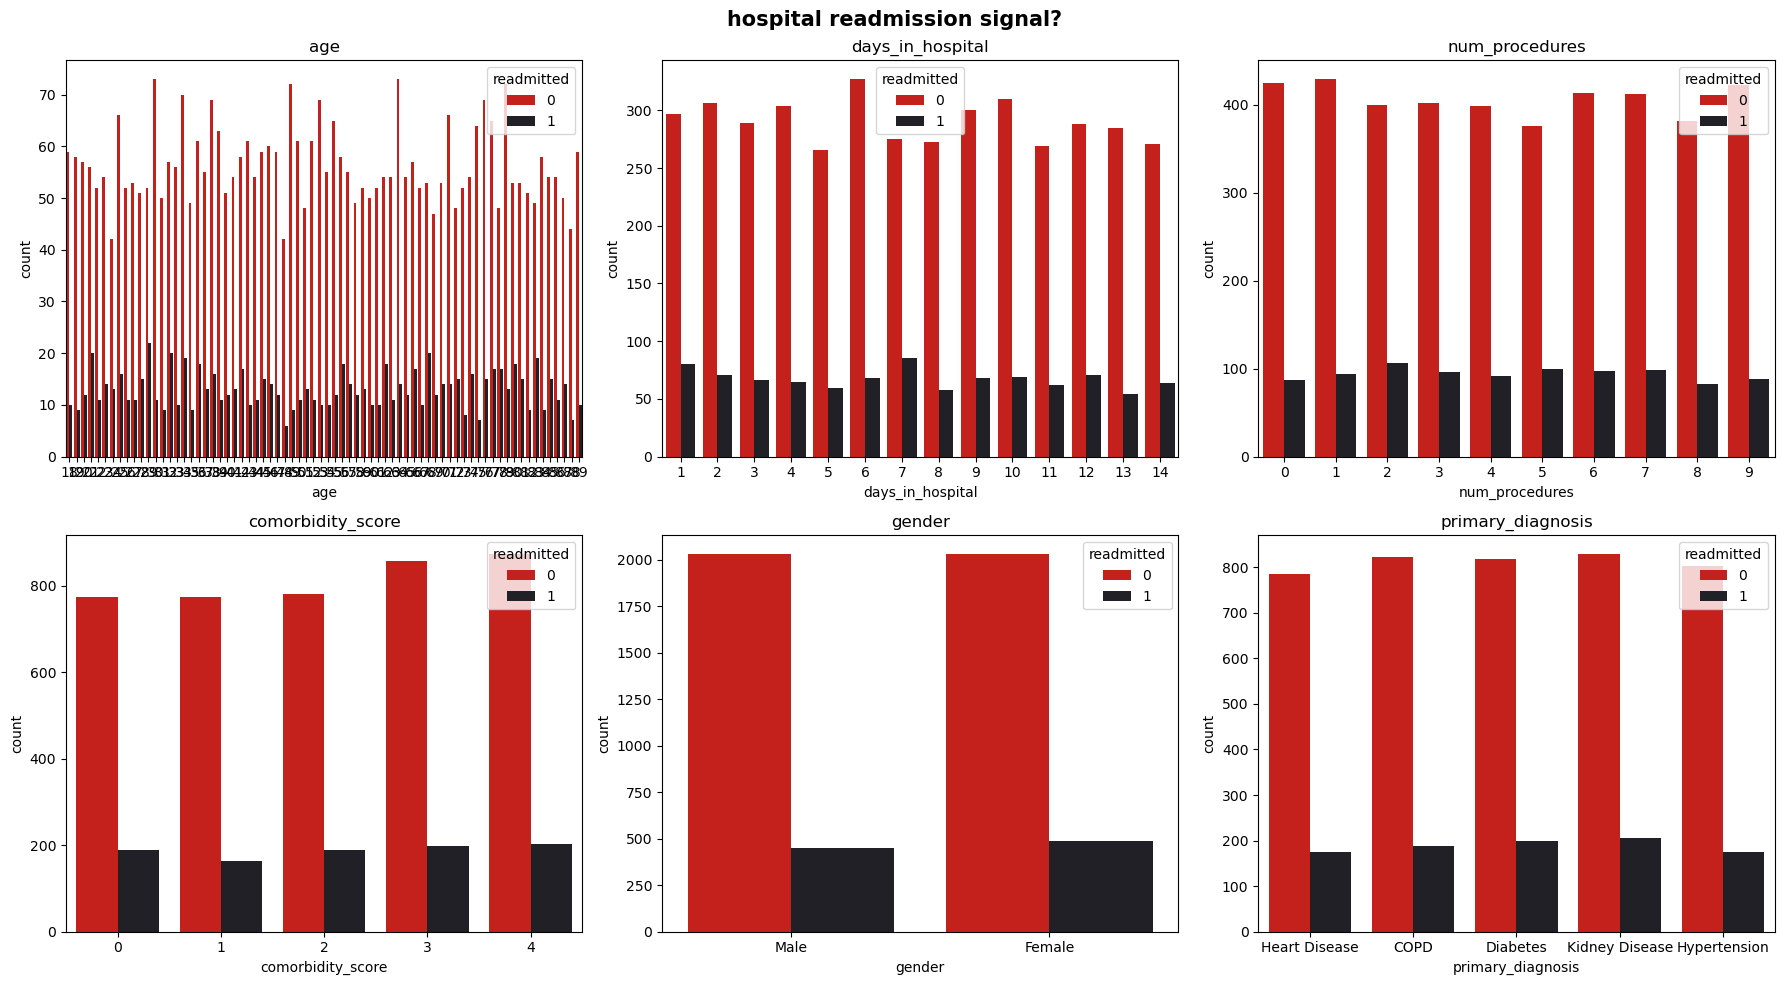

In [68]:
# readmission where values are only one

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('hospital readmission signal?', fontsize=15, fontweight='bold')
axes[0, 0].set_title('age')
sns.countplot(x='age',hue='readmitted',data=training_data,palette=[F1_RED,F1_GREY], ax=axes[0, 0])
axes[0, 1].set_title('days_in_hospital')    
sns.countplot(x='days_in_hospital',hue='readmitted',data=training_data,palette=[F1_RED,F1_GREY], ax=axes[0, 1])
axes[0, 2].set_title('num_procedures')
sns.countplot(x='num_procedures', hue='readmitted',data=training_data,palette=[F1_RED,F1_GREY], ax=axes[0, 2])
axes[1, 0].set_title('comorbidity_score')
sns.countplot(x='comorbidity_score',hue='readmitted',data=training_data,palette=[F1_RED,F1_GREY], ax=axes[1, 0])
axes[1, 1].set_title('gender')
sns.countplot(x='gender',hue='readmitted',data=training_data,palette=[F1_RED,F1_GREY], ax=axes[1, 1])
axes[1, 2].set_title('primary_diagnosis')
sns.countplot(x='primary_diagnosis',hue='readmitted',data=training_data,palette=[F1_RED,F1_GREY], ax=axes[1, 2])
plt.tight_layout()  
plt.show()

In [64]:
#top 4 numerical features correlated with readmission 
correlation_matrix = training_data_encoded.loc[:, ~training_data_encoded.columns.duplicated()].select_dtypes(include=[np.number]).corr()
correlation_with_target = correlation_matrix['readmitted'].abs().sort_values(ascending=False)
print(correlation_with_target[1:5])



days_in_hospital     0.009767
num_procedures       0.002721
age                  0.001610
comorbidity_score    0.001254
Name: readmitted, dtype: float64


Shape: (5000, 8)

Missing Values:
age                  0
gender               0
primary_diagnosis    0
num_procedures       0
days_in_hospital     0
comorbidity_score    0
discharge_to         0
readmitted           0
dtype: int64

Target Distribution:
readmitted
0    4060
1     940
Name: count, dtype: int64

Target Percentage:
readmitted
0    81.2
1    18.8
Name: proportion, dtype: float64


C:\Users\HOME\AppData\Local\Temp\ipykernel_29136\3791184398.py:63: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  eda.groupby(age_bins)['readmitted']
C:\Users\HOME\AppData\Local\Temp\ipykernel_29136\3791184398.py:91: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  eda.groupby(stay_bins)['readmitted']
C:\Users\HOME\AppData\Local\Temp\ipykernel_29136\3791184398.py:119: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  eda.groupby

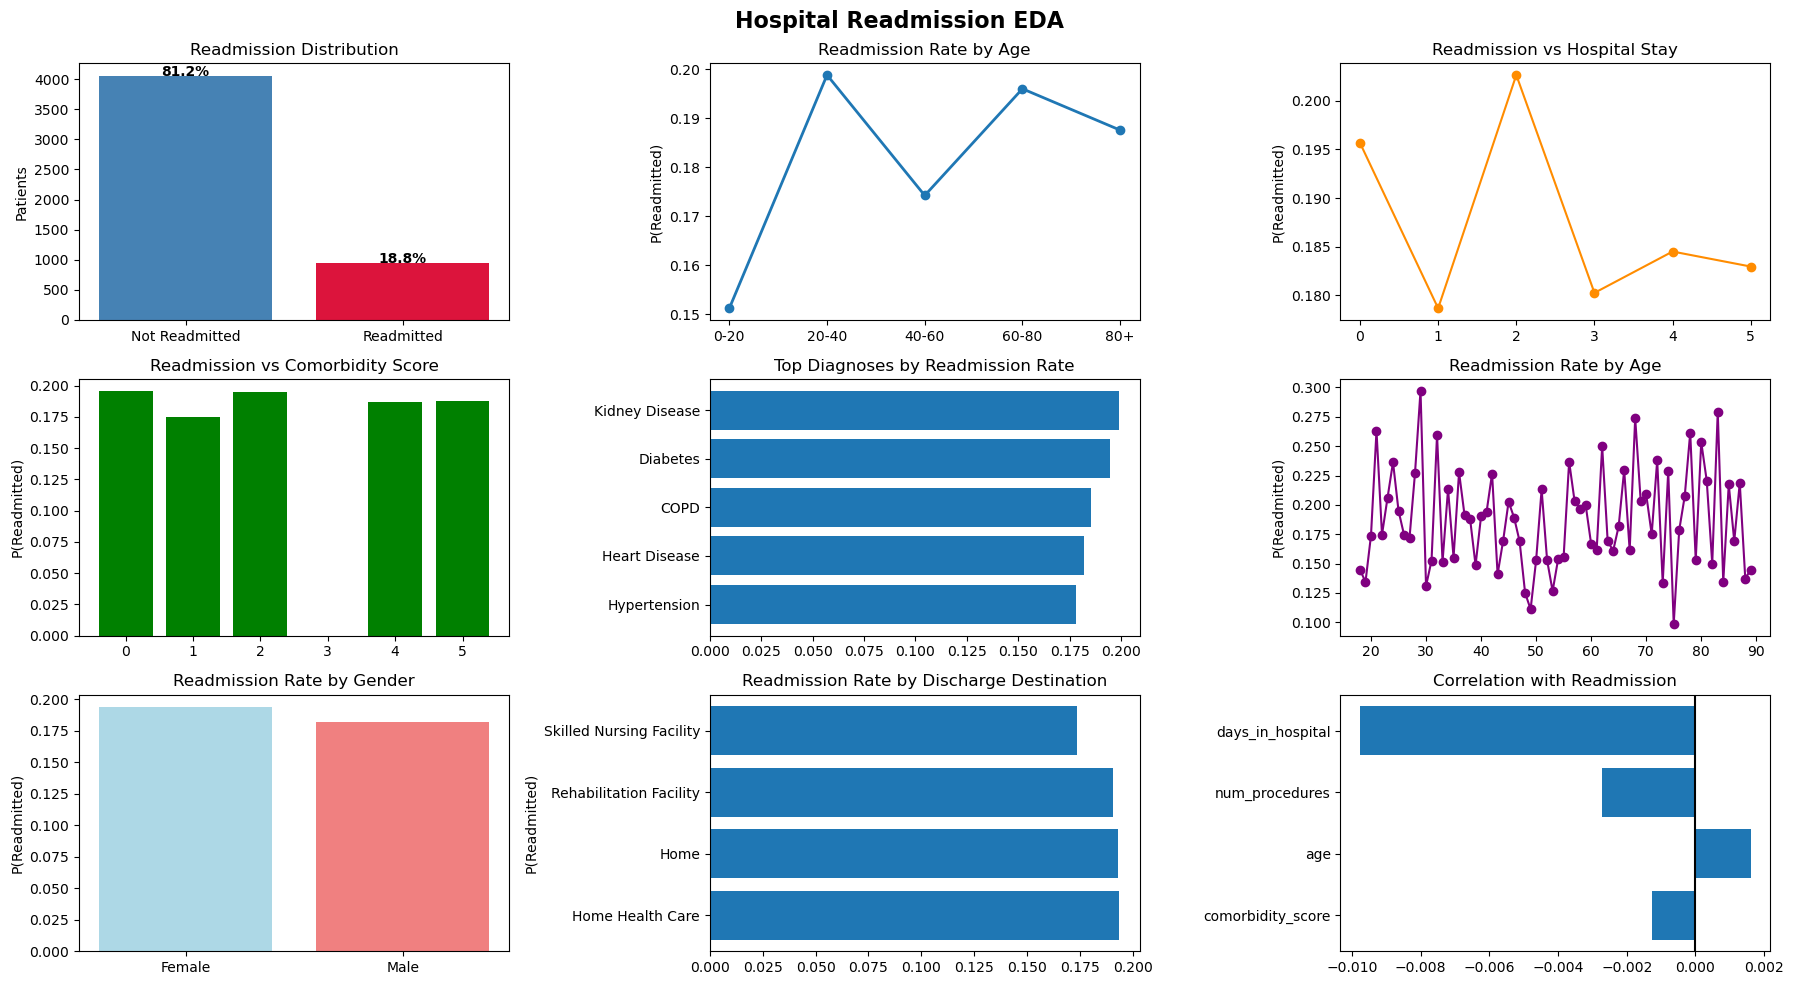

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Copy data
eda = training_data

# --------------------------
# Basic Information
# --------------------------
print("Shape:", eda.shape)
print("\nMissing Values:")
print(eda.isnull().sum())

print("\nTarget Distribution:")
print(eda['readmitted'].value_counts())
print("\nTarget Percentage:")
print(eda['readmitted'].value_counts(normalize=True) * 100)

# --------------------------
# Create Dashboard
# --------------------------
fig, axes = plt.subplots(3, 3, figsize=(18, 10))
fig.suptitle(
    'Hospital Readmission EDA',
    fontsize=16,
    fontweight='bold')

# =====================================
# 1. Target Distribution
# =====================================
counts = eda['readmitted'].value_counts().sort_index()
axes[0,0].bar(['Not Readmitted', 'Readmitted'],counts.values, color=['steelblue', 'crimson'])
for i, v in enumerate(counts.values):
    axes[0,0].text( i, v, f'{v/counts.sum():.1%}', ha='center',fontweight='bold')
axes[0,0].set_title('Readmission Distribution')
axes[0,0].set_ylabel('Patients')

# =====================================
# 2. Age vs Readmission
# =====================================
age_bins = pd.cut(
    eda['age'],
    bins=[0,20,40,60,80,100])

age_readmit = (
    eda.groupby(age_bins)['readmitted']
       .mean())

axes[0,1].plot(
    range(len(age_readmit)),
    age_readmit.values,
    marker='o',
    linewidth=2)

axes[0,1].set_xticks(range(len(age_readmit)))
axes[0,1].set_xticklabels(
    ['0-20','20-40','40-60','60-80','80+'])
axes[0,1].set_title('Readmission Rate by Age')
axes[0,1].set_ylabel('P(Readmitted)')

# =====================================
# 3. Days in Hospital
# =====================================
stay_bins = pd.cut(
    eda['days_in_hospital'],
    bins=6)

stay_readmit = (
    eda.groupby(stay_bins)['readmitted']
       .mean())

axes[0,2].plot(
    range(len(stay_readmit)),
    stay_readmit.values,
    marker='o',
    color='darkorange')

axes[0,2].set_title(
    'Readmission vs Hospital Stay')

axes[0,2].set_ylabel(
    'P(Readmitted)')

# =====================================
# 4. Comorbidity Score
# =====================================
comorb_bins = pd.cut(
    eda['comorbidity_score'],
    bins=6)

comorb_readmit = (
    eda.groupby(comorb_bins)['readmitted']
       .mean())

axes[1,0].bar(
    range(len(comorb_readmit)),
    comorb_readmit.values,
    color='green'
)

axes[1,0].set_title(
    'Readmission vs Comorbidity Score'
)

axes[1,0].set_ylabel(
    'P(Readmitted)'
)

# =====================================
# 5. Primary Diagnosis
# =====================================
diag_rates = (
    eda.groupby('primary_diagnosis')['readmitted']
       .mean()
       .sort_values(ascending=False)
       .head(10)
)

axes[1,1].barh(
    diag_rates.index,
    diag_rates.values
)

axes[1,1].set_title(
    'Top Diagnoses by Readmission Rate'
)

axes[1,1].invert_yaxis()


# =====================================
# 5. Age
# =====================================
age_readmit = (
    eda.groupby('age')['readmitted']
       .mean()
)
axes[1,2].plot(
    age_readmit.index,
    age_readmit.values,
    marker='o',
    color='purple'
)
axes[1,2].set_title(
    'Readmission Rate by Age'
)
axes[1,2].set_ylabel(
    'P(Readmitted)'
)

# =====================================
# 6. Gender
# =====================================
gender_rates = (eda.groupby('gender')['readmitted'].mean())
axes[2,0].bar(
    gender_rates.index,
    gender_rates.values,
    color=['lightblue', 'lightcoral'])
axes[2,0].set_title('Readmission Rate by Gender')
axes[2,0].set_ylabel( 'P(Readmitted)')

# =====================================
# 7. Discharge_to
# =====================================
discharge_rates = (
    eda.groupby('discharge_to')['readmitted']
       .mean()
       .sort_values(ascending=False))

axes[2,1].barh(
    discharge_rates.index,
    discharge_rates.values)

axes[2,1].set_title(
    'Readmission Rate by Discharge Destination')

axes[2,1].set_ylabel(
    'P(Readmitted)')

# =====================================
# 7. Correlations
# =====================================
numeric_cols = [
    'age',
    'num_procedures',
    'days_in_hospital',
    'comorbidity_score',
    'readmitted']

corr = (
    eda[numeric_cols]
    .corr()['readmitted']
    .drop('readmitted')
    .sort_values(key=abs, ascending=False))

axes[2,2].barh(
    corr.index,
    corr.values)

axes[2,2].set_title(
    'Correlation with Readmission')

axes[2,2].axvline(0, color='black')
axes[2,2].invert_yaxis()
plt.tight_layout()
plt.show()



In [6]:
#any missing values in the dataset
training_data.isnull().sum()    

age                  0
gender               0
primary_diagnosis    0
num_procedures       0
days_in_hospital     0
comorbidity_score    0
discharge_to         0
readmitted           0
dtype: int64

## Data Preprocessing: Encoding

In [85]:
#convert the categorical variables into numerical variables using one-hot encoding
training_data_encoded=pd.get_dummies(training_data,drop_first=True)
training_data_encoded.head()

,age,num_procedures,days_in_hospital,comorbidity_score,readmitted,gender_Male,primary_diagnosis_Diabetes,primary_diagnosis_Heart Disease,primary_diagnosis_Hypertension,primary_diagnosis_Kidney Disease,discharge_to_Home Health Care,discharge_to_Rehabilitation Facility,discharge_to_Skilled Nursing Facility
0,69,1,2,1,0,True,False,True,False,False,True,False,False
1,32,2,13,2,0,False,False,False,False,False,False,True,False
2,89,1,7,1,0,True,True,False,False,False,False,False,False
3,78,9,2,2,0,True,False,False,False,False,False,False,True
4,38,6,4,4,0,True,True,False,False,False,False,True,False


# Train/Validation Split

In [89]:
from sklearn.model_selection import train_test_split
x, y = training_data_encoded.drop('readmitted', axis=1), training_data_encoded['readmitted']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print(f"Train: {x_train.shape}, Test: {x_test.shape}, Scale weight: {scale_pos_weight:.2f}")

Train: (4000, 12), Test: (1000, 12), Scale weight: 4.32


# ML model - before balancing the dataset

# 1) Decision Tree

In [94]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier(max_depth=5, min_samples_leaf=100)
model.fit(x_train,y_train)  
y_pred=model.predict(x_test)
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test,y_pred))   
print(confusion_matrix(y_test,y_pred))   
accuracy= model.score(x_test, y_test)
print(f"Accuracy: {accuracy:.4f}") 


#print the true positive, false positive, true negative, false negative
tp, fp, tn, fn = confusion_matrix(y_test,y_pred).ravel()
print(f"TP: {tp}, FP: {fp}, TN: {tn}, FN: {fn}")
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
print(f"Precision: {precision:.4f}, Recall: {recall:.4f}")

              precision    recall  f1-score   support

           0       0.81      1.00      0.90       812
           1       0.00      0.00      0.00       188

    accuracy                           0.81      1000
   macro avg       0.41      0.50      0.45      1000
weighted avg       0.66      0.81      0.73      1000

[[812   0]
 [188   0]]
Accuracy: 0.8120
TP: 812, FP: 0, TN: 188, FN: 0
Precision: 1.0000, Recall: 1.0000


c:\Users\HOME\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\HOME\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\HOME\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# 2) XGboost with scale pos weight

In [95]:
#xgboost
from xgboost import XGBClassifier
xgb_model = XGBClassifier(scale_pos_weight=scale_pos_weight, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(x_train, y_train)
xgb_pred = xgb_model.predict(x_test)
print(classification_report(y_test,xgb_pred))
print(confusion_matrix(y_test,xgb_pred))

c:\Users\HOME\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [15:48:40] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0ed59c031377d09b8-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


              precision    recall  f1-score   support

           0       0.80      0.79      0.80       812
           1       0.16      0.17      0.16       188

    accuracy                           0.68      1000
   macro avg       0.48      0.48      0.48      1000
weighted avg       0.68      0.68      0.68      1000

[[643 169]
 [156  32]]


# 3) Logistic Regression

In [99]:
!pip install logistic-regression

ERROR: Could not find a version that satisfies the requirement logistic-regression (from versions: none)
ERROR: No matching distribution found for logistic-regression


In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(x_train, y_train)
log_pred = log_model.predict(x_test)
print(classification_report(y_test, log_pred))
print(confusion_matrix(y_test, log_pred))n

from logistic-regression import LogisticRegression
log_model = LogisticRegression()
log_model.fit(x_train, y_train)
log_pred = log_model.predict(x_test)
print(classification_report(y_test,log_pred))
print(confusion_matrix(y_test,log_pred))

SyntaxError: invalid syntax (2972324554.py, line 1)

In [84]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

x,y=training_data_encoded.drop('readmitted',axis=1),training_data_encoded['readmitted']
x_train_SMOTE,x_test,y_train_SMOTE,y_test=train_test_split(x,y,test_size=0.2,random_state=42) 
model=DecisionTreeClassifier(max_depth=5, min_samples_leaf=100)
model.fit(x_train_SMOTE,y_train)  
y_pred=model.predict(x_test)
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test,y_pred))   
print(confusion_matrix(y_test,y_pred))   
print(tp,fp,tf,ft=

SyntaxError: incomplete input (3344002271.py, line 12)

In [28]:
# data balancing using SMOTE
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
X=training_data_encoded.drop('readmitted',axis=1)
y=training_data_encoded['readmitted']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
smote=SMOTE(random_state=42)
X_train_smote,y_train_smote=smote.fit_resample(X_train,y_train)
#result from smote
print('Original dataset shape:', y_train.value_counts())
print('Resampled dataset shape:', y_train_smote.value_counts())

Original dataset shape: readmitted
0    3234
1     766
Name: count, dtype: int64
Resampled dataset shape: readmitted
0    3234
1    3234
Name: count, dtype: int64


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

x,y=training_data_encoded.drop('readmitted',axis=1),training_data_encoded['readmitted']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42) 
model=DecisionTreeClassifier()
#print the number of leafs in the decision tree
model.fit(x_train,y_train) 
y_pred=model.predict(x_test)
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test,y_pred))   
print(confusion_matrix(y_test,y_pred))  
print("Number of leafs in the decision tree:",model.get_n_leaves())
print("Depth of the decision tree:",model.get_depth())
  


              precision    recall  f1-score   support

           0       0.83      0.77      0.80       826
           1       0.17      0.22      0.19       174

    accuracy                           0.68      1000
   macro avg       0.50      0.50      0.50      1000
weighted avg       0.71      0.68      0.69      1000

[[637 189]
 [135  39]]
Number of leafs in the decision tree: 1112
Depth of the decision tree: 21


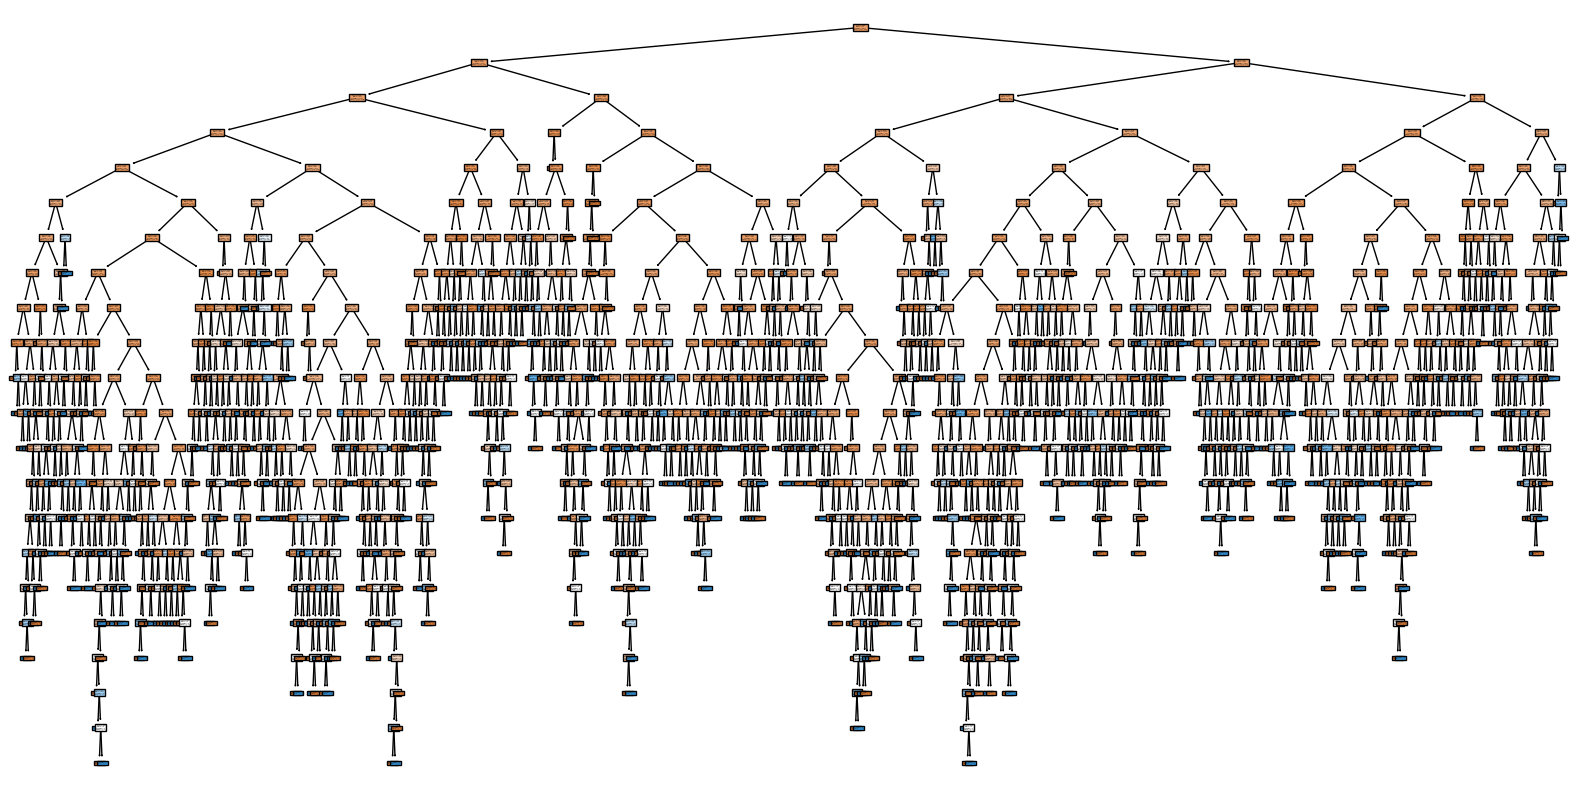

In [21]:
# visualize the decision tree
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(model,filled=True)
plt.show()

In [40]:
#give me an example from the dataset  in which the readmitted is one
training_data[training_data['readmitted']==1].head(1)   


,age,gender,primary_diagnosis,num_procedures,days_in_hospital,comorbidity_score,discharge_to,readmitted
19,66,Female,COPD,3,7,2,Home Health Care,1


In [10]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train,y_train)
y_pred_knn=knn.predict(x_test)
print(classification_report(y_test,y_pred_knn))

              precision    recall  f1-score   support

           0       0.83      0.96      0.89       826
           1       0.19      0.05      0.07       174

    accuracy                           0.80      1000
   macro avg       0.51      0.50      0.48      1000
weighted avg       0.72      0.80      0.75      1000



In [11]:
from sklearn.naive_bayes import MultinomialNB
nb=MultinomialNB()
nb.fit(x_train,y_train)     
y_pred_nb=nb.predict(x_test)
print(classification_report(y_test,y_pred_nb))

              precision    recall  f1-score   support

           0       0.83      1.00      0.90       826
           1       0.00      0.00      0.00       174

    accuracy                           0.83      1000
   macro avg       0.41      0.50      0.45      1000
weighted avg       0.68      0.83      0.75      1000



c:\Users\HOME\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\HOME\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\HOME\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [12]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression(max_iter=1000)
lr.fit(x_train,y_train) 
y_pred_lr=lr.predict(x_test)
print(classification_report(y_test,y_pred_lr))

              precision    recall  f1-score   support

           0       0.83      1.00      0.90       826
           1       0.00      0.00      0.00       174

    accuracy                           0.83      1000
   macro avg       0.41      0.50      0.45      1000
weighted avg       0.68      0.83      0.75      1000



c:\Users\HOME\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\HOME\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\HOME\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [13]:
from sklearn.svm import SVC
svm=SVC()
svm.fit(x_train,y_train)
y_pred_svm=svm.predict(x_test)
print(classification_report(y_test,y_pred_svm))

              precision    recall  f1-score   support

           0       0.83      1.00      0.90       826
           1       0.00      0.00      0.00       174

    accuracy                           0.83      1000
   macro avg       0.41      0.50      0.45      1000
weighted avg       0.68      0.83      0.75      1000



c:\Users\HOME\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\HOME\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\HOME\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [16]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=10,random_state=42)
rf.fit(x_train,y_train)
y_pred_rf=rf.predict(x_test)
print(classification_report(y_test,y_pred_rf))


              precision    recall  f1-score   support

           0       0.83      0.97      0.89       826
           1       0.17      0.03      0.05       174

    accuracy                           0.81      1000
   macro avg       0.50      0.50      0.47      1000
weighted avg       0.71      0.81      0.75      1000

